<a href="https://colab.research.google.com/github/Ramses-Monjaras/Data-Processing-Visualization/blob/main/Exam_2_Ramses_Monjaras_CPSMA_4313_Part_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Web scraping

In [2]:
url = "https://en.wikipedia.org/wiki/List_of_mountains_by_elevation"

import requests
import pandas as pa
from bs4 import BeautifulSoup

headers = {'User-Agent': 'Mozilla/5.0'}
r = requests.get(url, headers=headers)
html_contents = r.text
html_soup = BeautifulSoup(html_contents,"lxml")

In [9]:
tables = html_soup.find_all('table', class_="wikitable")

df = pa.read_html(str(tables))[0]

df.head()

/tmp/ipykernel_8452/2964763616.py:3: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pa.read_html(str(tables))[0]


,Mountain,Metres,Feet,Range,Location and notes
0,Mount Everest,8848,29029,Himalayas,Nepal/China
1,K2,8611,28251,Karakoram,Pakistan/China
2,Kangchenjunga,8586,28169,Himalayas,Nepal/India
3,Lhotse,8516,27940,Himalayas,Nepal – Climbers ascend Lhotse Face in climbin...
4,Makalu,8485,27838,Himalayas,Nepal


<Axes: xlabel='Range'>

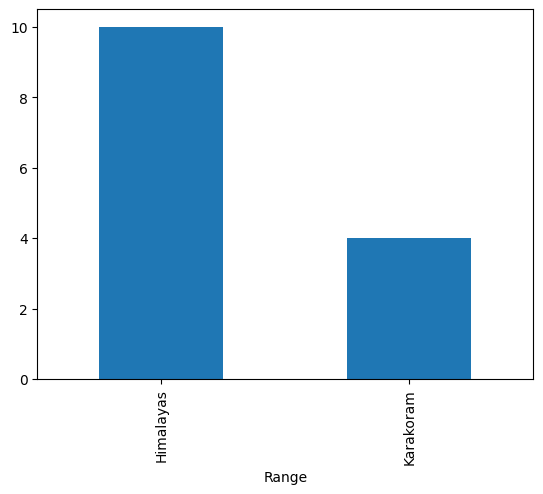

In [10]:
df.Range.value_counts().plot(kind = 'bar')

This bar chart shows that the Himalayas has more mountains in the 8,000 metres than the Karakoram

<Axes: >

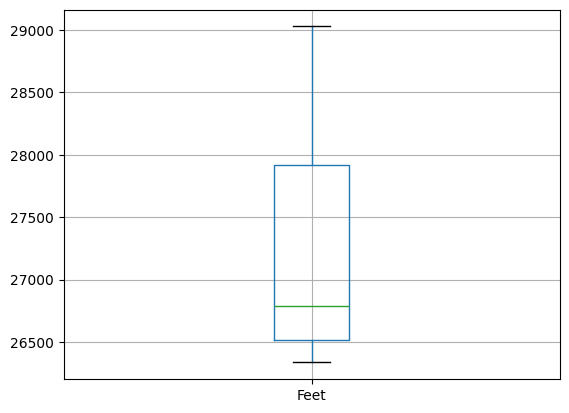

In [15]:
df.boxplot(column='Feet')

I notice from this box plot that there is no outliers which means the mountain's height are not too far apart from each other.

In [20]:
df.Feet.mean()

np.float64(27178.071428571428)

In [19]:
df.Feet.std()

879.4310629637179

The mean is 27178.071. The standard deviation is 879.43. The five point summary is min = 26,300, Q1 = 26,501, median = 26,700, Q3 = 27,900, max = 29,005.

In [28]:
df.groupby('Range').mean('Feet')

,Metres,Feet
Range,,
Himalayas,8319.70,27295.60
Karakoram,8194.25,26884.25


In [29]:
df.groupby('Range').median('Feet')

,Metres,Feet
Range,,
Himalayas,8177.5,26829.5
Karakoram,8065.5,26462.0


The mean for Himalayas is 27295.60 and for the Karakoram is 26884.25. The median for Himalayas is 26829.5 and for Karakoram is 26462.0.